In [26]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.callbacks import EarlyStopping

In [28]:
# 1. Tải và chuẩn bị dữ liệu
df = pd.read_csv('/kaggle/input/datasets/vncphongtrc/new-dataset/iaq_uba_dataset.csv')
X = df[['tvoc']].values  # Chỉ lấy TVOC làm đầu vào duy nhất [cite: 212]
y = df['iaq'].values     # Nhãn IAQ chuẩn UBA (1.0 - 5.0) [cite: 239]

# Chia tập dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Split train/test (80/20) - without shuffle to keep the contination of time

In [29]:
# 2. Chuẩn hóa dữ liệu (Rất quan trọng cho mạng Neural)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📈 Mean: {scaler.mean_[0]}")
print(f"📉 Scale: {scaler.scale_[0]}")

📈 Mean: 2812.118256623945
📉 Scale: 1904.0350619753567


Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.7432 - mae: 3.7432 - val_loss: 2.6072 - val_mae: 2.6072
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0456 - mae: 2.0456 - val_loss: 0.9719 - val_mae: 0.9719
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8808 - mae: 0.8808 - val_loss: 0.6386 - val_mae: 0.6386
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5590 - mae: 0.5590 - val_loss: 0.2905 - val_mae: 0.2905
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2147 - mae: 0.2147 - val_loss: 0.1574 - val_mae: 0.1574
Epoch 6/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1409 - mae: 0.1409 - val_loss: 0.1038 - val_mae: 0.1038
Epoch 7/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0933 - mae: 0.0933 - val_loss: 0.0860 - val_mae: 0.0860
Epoch 8/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0791 - mae: 0.0791 - val_loss: 0.0751 - val_mae: 0.0751
Epoch 9/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0670 - mae: 0.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


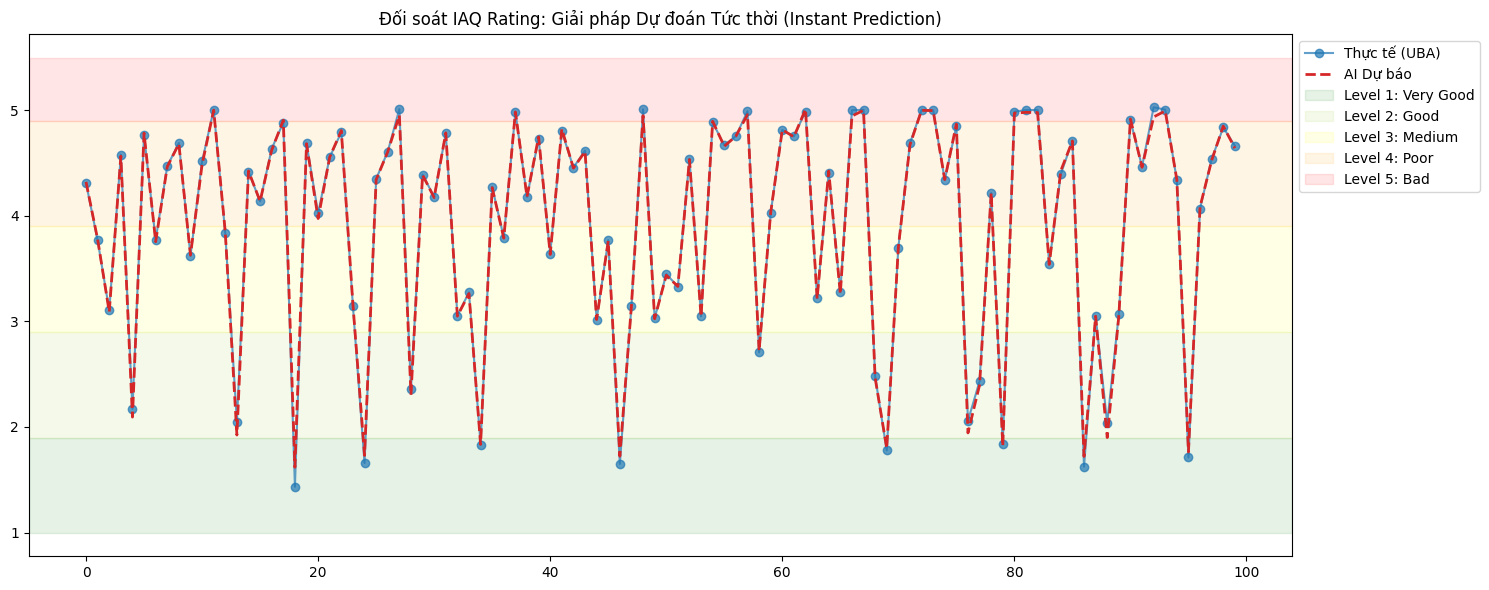

In [30]:
# 3. Xây dựng mô hình MLP cải tiến (32-16-1)
# Cấu trúc này vẫn đủ nhỏ để nằm trong 20-40kB flash của MCU 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(1,)), 
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1) 
])

# Sử dụng loss MAE để AI nhạy hơn với các điểm cực trị
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='mae', 
              metrics=['mae'])

# Early Stopping để tránh học vẹt (Overfitting)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 4. Huấn luyện
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 5. Lưu Model và dự đoán thử
model.save('backend/IAQ_model.h5')
y_pred = model.predict(X_test_scaled)

# 6. Vẽ biểu đồ đối soát (Giữ nguyên hàm vẽ vùng màu UBA của bạn)
def plot_final_comparison(y_true, y_pred, num_samples=100):
    plt.figure(figsize=(15, 6))
    plt.plot(y_true[:num_samples], label='Thực tế (UBA)', color='#1f77b4', marker='o', alpha=0.7)
    plt.plot(y_pred[:num_samples], label='AI Dự báo', color='#d62728', linestyle='--', linewidth=2)
    
    # Vẽ các vùng màu UBA [cite: 239]
    plt.axhspan(1.0, 1.9, color='green', alpha=0.1, label='Level 1: Very Good')
    plt.axhspan(1.9, 2.9, color='yellowgreen', alpha=0.1, label='Level 2: Good')
    plt.axhspan(2.9, 3.9, color='yellow', alpha=0.1, label='Level 3: Medium')
    plt.axhspan(3.9, 4.9, color='orange', alpha=0.1, label='Level 4: Poor')
    plt.axhspan(4.9, 5.5, color='red', alpha=0.1, label='Level 5: Bad')
    
    plt.title('Đối soát IAQ Rating: Giải pháp Dự đoán Tức thời (Instant Prediction)')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

plot_final_comparison(y_test, y_pred)


**Visualizing History**

*Sau khi chạy xong đoạn code của bạn, hãy thêm đoạn này để xem đường cong của Loss và MAE. Nếu đường màu cam (Validation) bắt đầu tăng lên trong khi đường màu xanh (Train) vẫn giảm, nghĩa là mô hình đang học vẹt.*

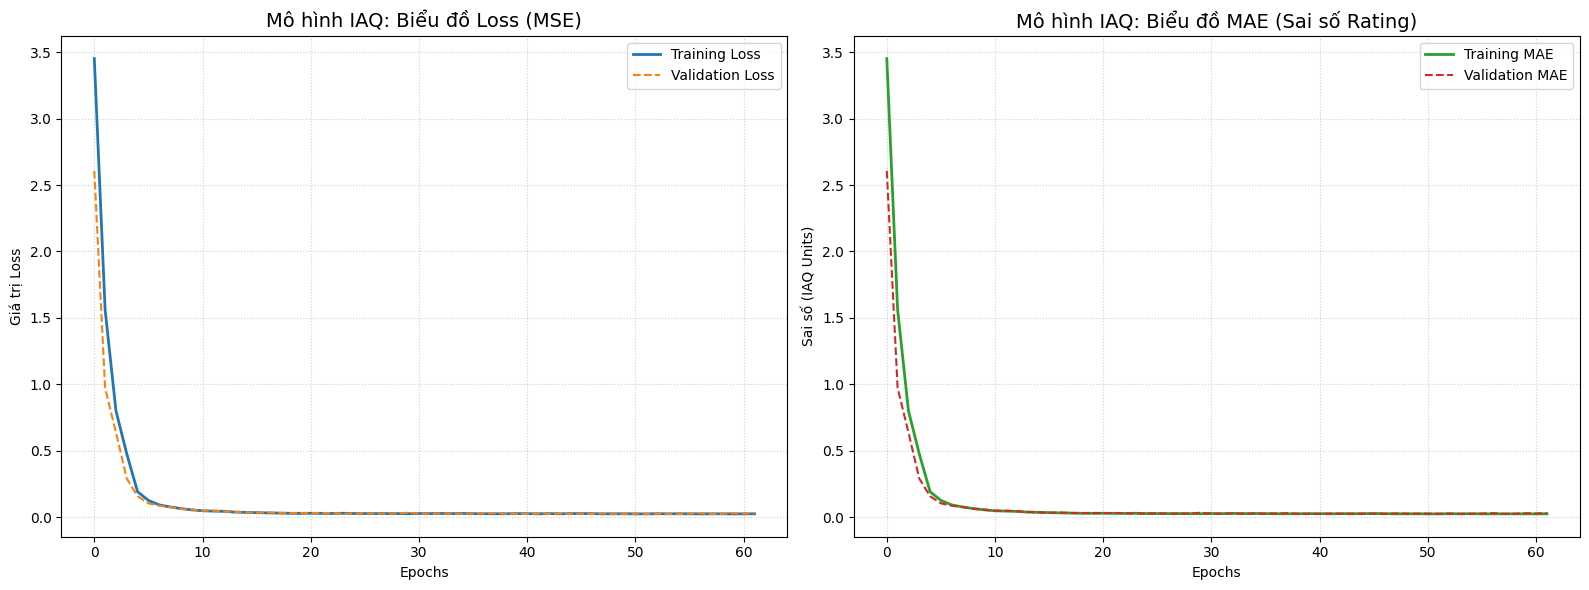

In [31]:

def plot_training_results(history):
    """
    Vẽ biểu đồ Loss và MAE để đánh giá độ hội tụ và sai số của mô hình IAQ.
    """
    # Tạo khung hình gồm 2 biểu đồ con
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Biểu đồ Loss (Mean Squared Error)
    # Thể hiện sự tối ưu hóa trọng số để khớp với chuẩn UBA [cite: 231, 234]
    ax1.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linestyle='--')
    ax1.set_title('Mô hình IAQ: Biểu đồ Loss (MSE)', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Giá trị Loss')
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # 2. Biểu đồ MAE (Mean Absolute Error)
    # Thể hiện sai số trực tiếp trên thang điểm IAQ (1.0 - 5.0) [cite: 239]
    ax2.plot(history.history['mae'], label='Training MAE', color='#2ca02c', linewidth=2)
    ax2.plot(history.history['val_mae'], label='Validation MAE', color='#d62728', linestyle='--')
    ax2.set_title('Mô hình IAQ: Biểu đồ MAE (Sai số Rating)', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Sai số (IAQ Units)')
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    # Thêm thông tin chú thích về hiệu năng mục tiêu 
    plt.tight_layout()
    plt.show()

# Sau khi fit xong, gọi hàm này để xem kết quả
plot_training_results(history)


**Khi đường Train Loss và Validation Loss cùng giảm dần đến một ngưỡng nhất định rồi bắt đầu đi ngang (flatten out), đây là một dấu hiệu cực kỳ tích cực.Trong kỹ thuật học máy, hiện tượng này được gọi là Sự hội tụ (Convergence)**


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


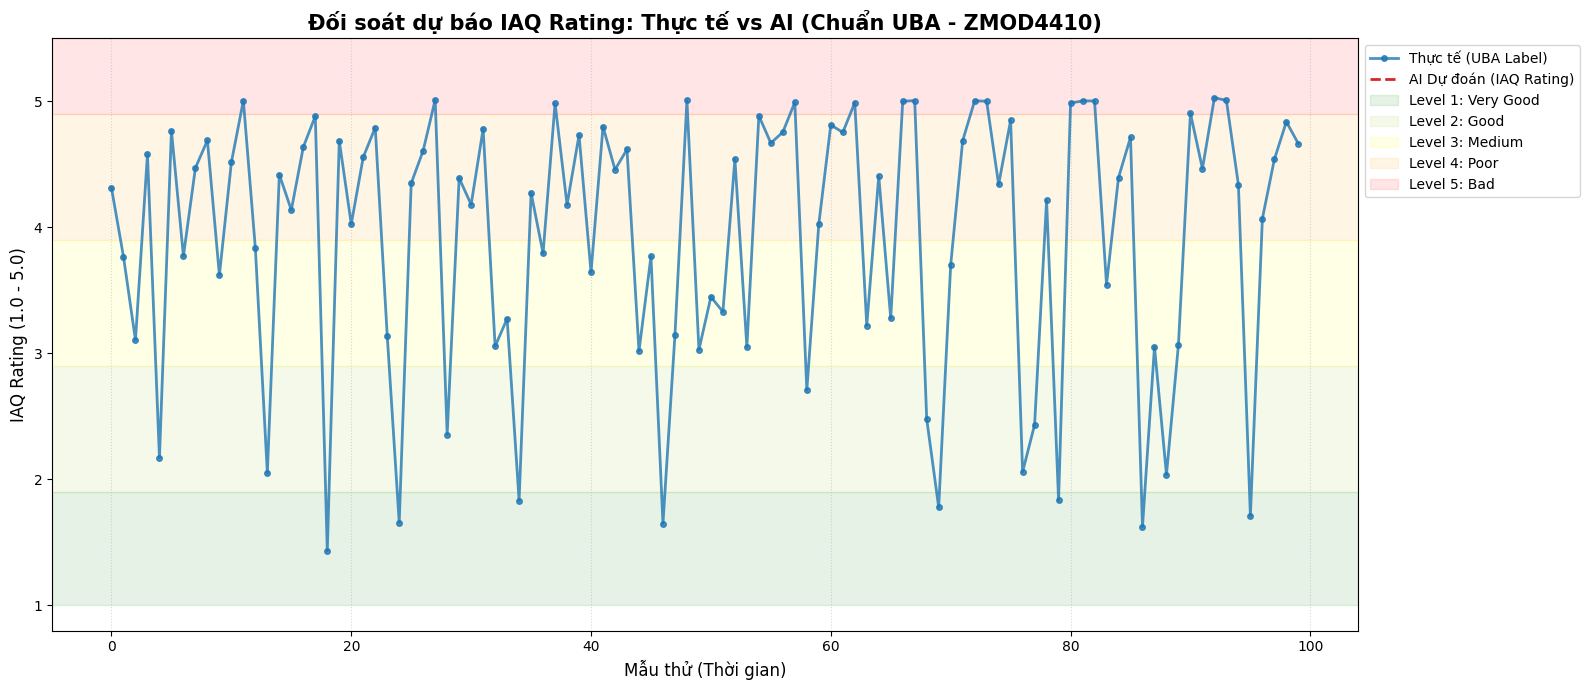

In [33]:
import matplotlib.pyplot as plt
import numpy as np

model = tf.keras.models.load_model('/kaggle/working/backend/IAQ_model.h5', compile=False)

y_pred = model.predict(X_test)

def plot_iaq_comparison(y_true, y_pred, num_samples=100):
    plt.figure(figsize=(16, 7))
    
    # Vẽ đường thực tế và dự đoán
    plt.plot(y_true[:num_samples], label='Thực tế (UBA Label)', color='#1f77b4', linewidth=2, marker='o', markersize=4, alpha=0.8)
    plt.plot(y_pred[:num_samples], label='AI Dự đoán (IAQ Rating)', color='#d62728', linestyle='--', linewidth=2)

    # --- ĐÁNH DẤU CÁC NGƯỠNG UBA (Trang 10 Datasheet)  ---
    thresholds = [1.9, 2.9, 3.9, 4.9]
    colors = ['green', 'yellowgreen', 'yellow', 'orange', 'red']
    labels = ['Very Good', 'Good', 'Medium', 'Poor', 'Bad']
    
    # Vẽ các vùng màu đại diện cho chất lượng không khí
    plt.axhspan(1.0, 1.9, color='green', alpha=0.1, label='Level 1: Very Good')
    plt.axhspan(1.9, 2.9, color='yellowgreen', alpha=0.1, label='Level 2: Good')
    plt.axhspan(2.9, 3.9, color='yellow', alpha=0.1, label='Level 3: Medium')
    plt.axhspan(3.9, 4.9, color='orange', alpha=0.1, label='Level 4: Poor')
    plt.axhspan(4.9, 5.5, color='red', alpha=0.1, label='Level 5: Bad')

    # Cấu hình trục và tiêu đề
    plt.title('Đối soát dự báo IAQ Rating: Thực tế vs AI (Chuẩn UBA - ZMOD4410)', fontsize=15, fontweight='bold')
    plt.xlabel('Mẫu thử (Thời gian)', fontsize=12)
    plt.ylabel('IAQ Rating (1.0 - 5.0)', fontsize=12)
    plt.ylim(0.8, 5.5) # Giới hạn thang điểm IAQ 
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    plt.grid(axis='x', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- Cách gọi hàm ---
plot_iaq_comparison(y_test, y_pred, num_samples=100)

In [ ]:
# Save file on Kaggle
model.save("IAQ_model.h5")